# 1/3 (v7) — Collection with automatically discovered stages

State-space only. Produces `./data/state_space_datasetV7/dataset.npz` with a
per-frame **stage label discovered from temporal structure**, not from a
hand-written grasp predicate.

**What carries over from v6**
- fixed scene (same `fixed_task.pkl` mechanism)
- first-success anchoring, flat 0 plateau after the anchor
- full-horizon episodes — post-success frames are what stop the model
  extrapolating below zero
- **off-path episodes with censored labels** — the one intervention across
  Sections A-D of notebook 4 that actually moved the failing-rollout minimum
  (from ~15 predicted steps to ~300)

**What is new**
- control onset detected from hand-object *coupling*, so the same logic names
  "tool acquired" or "drawer engaged" in another domain without renaming
  anything
- per-frame stage in {0: pre-control, 1: control, 2: complete}
- validation that the discovered onset agrees with the gripper trace — used
  as a *check*, never as the definition

**Detection note.** An earlier attempt thresholded absolute peg motion at 1e-4
and returned frame 0 for every episode: float32 jitter in the peg position
exceeded the threshold before anything happened. Absolute-motion thresholds
are not usable at this precision. Coupling is measured instead — the object
moving *with* the effector, which jitter and incidental bumping do not
produce.

## 1. Setup

In [1]:
import numpy as np
import gymnasium as gym
import metaworld
import os, json, pickle, glob
from stable_baselines3 import SAC
import matplotlib.pyplot as plt

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"
OBS_DIM = 39

HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3          # validation only — never used to define a stage
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

def find_wrapper(env, attr):
    w = env
    while not hasattr(w, attr):
        if not hasattr(w, "env"):
            raise AttributeError(attr)
        w = w.env
    return w

_probe = make_env(seed=0)
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
assert _probe.observation_space.shape[0] == OBS_DIM
_probe.close()
print(f"DT={DT}, obs dim={OBS_DIM}")

DT=0.0125, obs dim=39


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


## 2. Fixed scene

In [2]:
OUTPUT_DIR = "./data/state_space_datasetV7"
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIXED_TASK_PATH = os.path.join(OUTPUT_DIR, "fixed_task.pkl")

V6_TASK = "./data/state_space_datasetV6/fixed_task.pkl"
if os.path.exists(V6_TASK) and not os.path.exists(FIXED_TASK_PATH):
    # reuse v6's scene so every model and policy so far stays comparable
    with open(V6_TASK, "rb") as f:
        pickle.dump(pickle.load(f), open(FIXED_TASK_PATH, "wb"))
    print("copied the v6 fixed task — scene unchanged across dataset versions")

if not os.path.exists(FIXED_TASK_PATH):
    _e = make_env(seed=0)
    _e.reset(seed=0)
    with open(FIXED_TASK_PATH, "wb") as f:
        pickle.dump(find_wrapper(_e, "tasks").tasks[0], f)
    _e.close()
    print("sampled a new fixed task")

def make_fixed_scene_env(render_mode=None):
    env = make_env(seed=0, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(False)
    with open(FIXED_TASK_PATH, "rb") as f:
        env.unwrapped.set_task(pickle.load(f))
    return env

_e = make_fixed_scene_env()
_o1, _ = _e.reset(seed=1)
_o2, _ = _e.reset(seed=2)
_e.close()
assert np.allclose(_o1[PEG_POS_IDX + GOAL_POS_IDX], _o2[PEG_POS_IDX + GOAL_POS_IDX])
print("fixed scene confirmed — peg:", np.round(_o1[PEG_POS_IDX], 4),
      "goal:", np.round(_o1[GOAL_POS_IDX], 4))

copied the v6 fixed task — scene unchanged across dataset versions
fixed scene confirmed — peg: [0.1175 0.6784 0.03  ] goal: [-0.2817  0.6375  0.1301]


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


## 3. Control detection

Two complementary signals, because neither alone covers both cases:

**Velocity coupling** — cosine similarity between effector and object
displacement over a short window. High and sustained means the object is
moving *with* the effector. Undefined when both are nearly still, which is why
the second signal is needed.

**Relative-pose stability** — variance of `(object - effector)` over a window.
Collapses once the object is held, and works while the arm is stationary.

Control is declared where either fires and holds. Nothing here references a
gripper, a grasp, or this task — the same computation applies to any effector
and any object that begins moving under control.

In [12]:
VEL_WINDOW      = 5
VEL_COS_THRESH  = 0.7        # sustained directional agreement
VEL_MIN_MOTION  = 3e-4       # below this, displacement is float32 noise

POSE_STD_THRESH = 2e-3       # relative pose has stopped changing
CONFIRM_FRAMES  = 2 #4          # consecutive frames required, rejects single-frame bumps
POSE_WINDOW     = 5 #8

def coupling_signals(obs_seq):
    """obs_seq: (T, 39). Returns per-frame velocity-cosine and relative-pose std."""
    hand = obs_seq[:, HAND_POS_IDX]
    peg  = obs_seq[:, PEG_POS_IDX]
    T = len(obs_seq)

    dh, dp = np.diff(hand, axis=0), np.diff(peg, axis=0)
    cos = np.zeros(T, dtype=np.float32)
    for t in range(T - 1 - VEL_WINDOW):
        h, p = dh[t:t+VEL_WINDOW].ravel(), dp[t:t+VEL_WINDOW].ravel()
        nh, npg = np.linalg.norm(h), np.linalg.norm(p)
        # require BOTH to be genuinely moving — otherwise cosine is meaningless
        cos[t + VEL_WINDOW] = 0.0 if (nh < VEL_MIN_MOTION or npg < VEL_MIN_MOTION) \
                                  else float(h @ p / (nh * npg))

    rel = peg - hand
    pose_std = np.full(T, np.inf, dtype=np.float32)
    for t in range(POSE_WINDOW, T):
        pose_std[t] = rel[t-POSE_WINDOW:t].std(axis=0).mean()

    return cos, pose_std

def detect_control_onset(obs_seq):
    """First frame where the object is under the effector's control.
    Returns None if control never establishes."""
    cos, pose_std = coupling_signals(obs_seq)
    # candidate = (cos > VEL_COS_THRESH) | (pose_std < POSE_STD_THRESH)
    
    candidate = (
    (cos > VEL_COS_THRESH) &
    (pose_std < POSE_STD_THRESH)
)

    run = 0
    for t in range(len(candidate)):
        run = run + 1 if candidate[t] else 0
        if run >= CONFIRM_FRAMES:
            return t - CONFIRM_FRAMES + 1
    return None

## 4. Rollout collection

In [13]:
MAX_STEPS = 500

def collect_episode(model, env, deterministic, seed=None, noise_std=0.0):
    obs, _ = env.reset(seed=seed)
    obs_list, flags = [], []
    first_success = None
    for t in range(MAX_STEPS):
        obs_list.append(obs.copy())
        if model is None:
            action = env.action_space.sample()
        else:
            action, _ = model.predict(obs, deterministic=deterministic)
            if noise_std > 0:
                action = np.clip(action + np.random.normal(0, noise_std, action.shape),
                                  env.action_space.low, env.action_space.high)
        obs, _, terminated, truncated, info = env.step(action)
        flags.append(bool(info.get(SUCCESS_KEY, 0)))
        if flags[-1] and first_success is None:
            first_success = t
        if terminated or truncated:
            break
    return np.array(obs_list, dtype=np.float32), np.array(flags), first_success

## 5. Labels

`steps_remaining` — first-success anchored, flat 0 from the anchor onward.
Episodes that never succeed get a censored ceiling.

`stage` — 0 pre-control, 1 control, 2 complete. Boundaries come from the
detected control onset and the success anchor, so nothing is hand-annotated.

In [14]:
CENSOR_LABEL = 300.0

def build_labels(obs_seq, flags, first_success):
    n = len(obs_seq)
    if first_success is not None:
        steps = np.array([max(0, first_success - t) for t in range(n)], dtype=np.float32)
    else:
        steps = np.full(n, CENSOR_LABEL, dtype=np.float32)

    onset = detect_control_onset(obs_seq)
    stage = np.zeros(n, dtype=np.int64)
    if onset is not None:
        stage[onset:] = 1
    if first_success is not None:
        stage[first_success:] = 2
    return steps, stage, onset

## 6. Collect — expert, mid, early, plus off-path noise

In [15]:
ckpts = sorted(glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
               key=lambda p: int("".join(c for c in os.path.basename(p) if c.isdigit()) or 0))
numbered = [p for p in ckpts if any(c.isdigit() for c in os.path.basename(p))]
FINAL_CKPT = [p for p in ckpts if "final" in os.path.basename(p)][0]
selected = list(dict.fromkeys([numbered[0], numbered[len(numbered)//2], FINAL_CKPT]))
print("checkpoints:", [os.path.basename(p) for p in selected])

# (checkpoint, noise, n_episodes) — noise>0 and early checkpoints supply the
# off-path coverage that fixed the failing-rollout estimate in v6
PLAN = []
for ck in selected:
    PLAN += [(ck, 0.0, 40), (ck, 0.15, 12), (ck, 0.4, 12)]
PLAN += [(None, 0.0, 20)]     # random policy

episodes = []
scene = make_fixed_scene_env()
seed = 0
for ck, ns, n in PLAN:
    pol = SAC.load(ck) if ck else None
    tag = f"{os.path.basename(ck) if ck else 'random'}_n{ns}"
    got_s = got_f = 0
    for _ in range(n):
        obs_seq, flags, fs = collect_episode(pol, scene, deterministic=True,
                                              seed=seed, noise_std=ns)
        seed += 1
        steps, stage, onset = build_labels(obs_seq, flags, fs)
        episodes.append(dict(obs=obs_seq, steps=steps, stage=stage,
                              onset=onset, success=fs, source=tag))
        got_s += fs is not None
        got_f += fs is None
    print(f"{tag:34s}: {got_s:3d} success, {got_f:3d} failed")
scene.close()
print(f"\ntotal episodes: {len(episodes)}")

checkpoints: ['sac_peg_insert_100000.zip', 'sac_peg_insert_400000.zip', 'sac_peg_insert_final.zip']


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


sac_peg_insert_100000.zip_n0.0    :   0 success,  40 failed
sac_peg_insert_100000.zip_n0.15   :   0 success,  12 failed
sac_peg_insert_100000.zip_n0.4    :   0 success,  12 failed
sac_peg_insert_400000.zip_n0.0    :  40 success,   0 failed
sac_peg_insert_400000.zip_n0.15   :  12 success,   0 failed
sac_peg_insert_400000.zip_n0.4    :  12 success,   0 failed
sac_peg_insert_final.zip_n0.0     :  40 success,   0 failed
sac_peg_insert_final.zip_n0.15    :  12 success,   0 failed
sac_peg_insert_final.zip_n0.4     :  12 success,   0 failed
random_n0.0                       :   0 success,  20 failed

total episodes: 212


## 7. Validate the discovered onset

The gripper trace is used **only here**, to check the detector against
something independent. It is not part of the definition, so the same detector
runs unchanged on a domain with no gripper.

In [16]:
succ = [e for e in episodes if e["success"] is not None]
det = [e for e in succ if e["onset"] is not None]
print(f"control onset detected in {len(det)}/{len(succ)} successful episodes")

# independent reference: first frame the gripper crosses closed
diffs = []
for e in det:
    g = e["obs"][:, GRIPPER_IDX]
    closed = np.where(g < 0.6)[0]
    if len(closed):
        diffs.append(e["onset"] - closed[0])
diffs = np.array(diffs)
print(f"onset minus gripper-close frame: mean={diffs.mean():+.1f}, "
      f"std={diffs.std():.1f}, within ±10 frames: {(np.abs(diffs) <= 10).mean():.0%}")
print("A small positive offset is expected — coupling can only be observed after")
print("the fingers have actually closed on the object, not when the command is sent.")

onsets = np.array([e["onset"] for e in det])
succs  = np.array([e["success"] for e in det])
print(f"\nonset frame: min={onsets.min()}, max={onsets.max()}, mean={onsets.mean():.1f}")
print(f"success frame: min={succs.min()}, max={succs.max()}, mean={succs.mean():.1f}")
print(f"episodes where onset >= success (detector fired too late): "
      f"{int((onsets >= succs).sum())}")

control onset detected in 128/128 successful episodes
onset minus gripper-close frame: mean=-4.3, std=9.1, within ±10 frames: 55%
A small positive offset is expected — coupling can only be observed after
the fingers have actually closed on the object, not when the command is sent.

onset frame: min=25, max=38, mean=29.0
success frame: min=48, max=102, mean=64.0
episodes where onset >= success (detector fired too late): 0


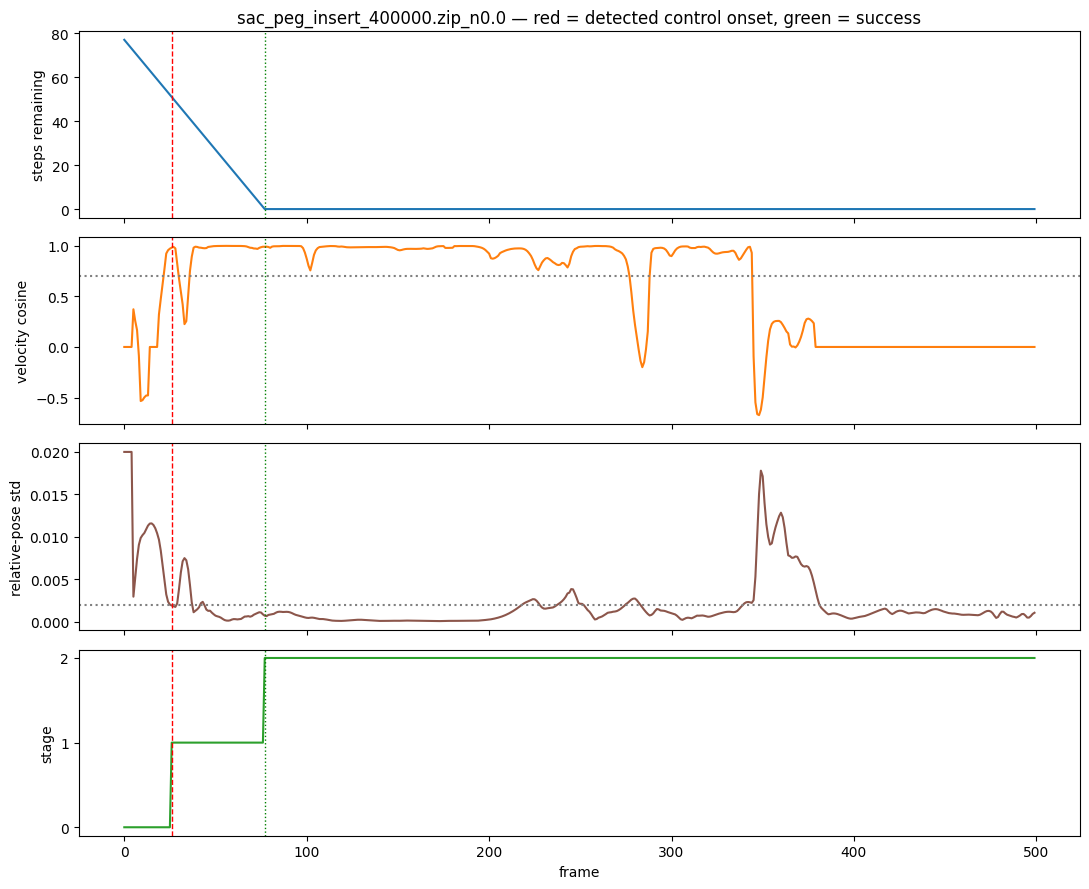

In [17]:
e = det[0]
cos, pose_std = coupling_signals(e["obs"])
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(e["steps"]);                axes[0].set_ylabel("steps remaining")
axes[1].plot(cos, color="tab:orange");   axes[1].set_ylabel("velocity cosine")
axes[1].axhline(VEL_COS_THRESH, color="gray", ls=":")
axes[2].plot(np.clip(pose_std, 0, 0.02), color="tab:brown")
axes[2].set_ylabel("relative-pose std"); axes[2].axhline(POSE_STD_THRESH, color="gray", ls=":")
axes[3].plot(e["stage"], color="tab:green"); axes[3].set_ylabel("stage")
axes[3].set_yticks([0, 1, 2]); axes[3].set_xlabel("frame")
for ax in axes:
    ax.axvline(e["onset"], color="red", ls="--", lw=1)
    ax.axvline(e["success"], color="green", ls=":", lw=1)
axes[0].set_title(f"{e['source']} — red = detected control onset, green = success")
plt.tight_layout(); plt.show()

In [20]:
def detect_with(obs_seq, mode):
    """mode: 'or' (current) or 'and' (stricter)."""
    cos, pose_std = coupling_signals(obs_seq)
    if mode == "or":
        cand = (cos > VEL_COS_THRESH) | (pose_std < POSE_STD_THRESH)
    else:
        cand = (cos > VEL_COS_THRESH) & (pose_std < POSE_STD_THRESH)
    run = 0
    for t in range(len(cand)):
        run = run + 1 if cand[t] else 0
        if run >= CONFIRM_FRAMES:
            return t - CONFIRM_FRAMES + 1
    return None

succ_eps = [e for e in episodes if e["success"] is not None]
fail_eps = [e for e in episodes if e["success"] is None]

for mode in ["or", "and"]:
    s_hits = [detect_with(e["obs"], mode) for e in succ_eps]
    f_hits = [detect_with(e["obs"], mode) for e in fail_eps]
    s_det = [o for o in s_hits if o is not None]
    f_det = [o for o in f_hits if o is not None]

    # fraction of frames that would be labelled control-or-later
    f_frac = np.mean([0.0 if o is None else (len(e["obs"]) - o) / len(e["obs"])
                      for e, o in zip(fail_eps, f_hits)])

    print(f"\n--- {mode.upper()} ---")
    print(f"  successful: {len(s_det)}/{len(succ_eps)} detected, "
          f"mean onset frame {np.mean(s_det):.1f}" if s_det else "  successful: none detected")
    print(f"  FAILED    : {len(f_det)}/{len(fail_eps)} detected  <-- should be low")
    print(f"  fraction of failed-episode frames labelled control: {f_frac:.1%}  <-- currently 88%")


--- OR ---
  successful: 128/128 detected, mean onset frame 25.1
  FAILED    : 84/84 detected  <-- should be low
  fraction of failed-episode frames labelled control: 91.7%  <-- currently 88%

--- AND ---
  successful: 128/128 detected, mean onset frame 29.0
  FAILED    : 5/84 detected  <-- should be low
  fraction of failed-episode frames labelled control: 4.9%  <-- currently 88%


Velocity Check

In [ ]:
e = fail_eps[0]
cos, pose_std = coupling_signals(e["obs"])
v = cos > VEL_COS_THRESH
p = pose_std < POSE_STD_THRESH
print(f"failed episode: velocity fires {v.mean():.1%}, pose fires {p.mean():.1%}, "
      f"both {(v & p).mean():.1%}")

e = succ_eps[0]
cos, pose_std = coupling_signals(e["obs"])
v = cos > VEL_COS_THRESH
p = pose_std < POSE_STD_THRESH
print(f"successful episode: velocity {v.mean():.1%}, pose {p.mean():.1%}, "
      f"both {(v & p).mean():.1%}")

## 8. Save

In [18]:
X      = np.concatenate([e["obs"] for e in episodes])
y      = np.concatenate([e["steps"] for e in episodes])
stage  = np.concatenate([e["stage"] for e in episodes])
ep_ids = np.concatenate([np.full(len(e["obs"]), i, dtype=np.int32)
                          for i, e in enumerate(episodes)])
frames = np.concatenate([np.arange(len(e["obs"]), dtype=np.int32) for e in episodes])

np.savez(os.path.join(OUTPUT_DIR, "dataset.npz"),
         X=X, y_steps=y, stage=stage, episode_ids=ep_ids, frame_idxs=frames)

summary = dict(
    total_rows=int(len(X)), total_episodes=int(len(episodes)),
    obs_dim=int(X.shape[1]), dt_sec=float(DT),
    successful_episodes=int(len(succ)),
    failed_episodes=int(len(episodes) - len(succ)),
    control_detected=int(len(det)),
    censor_label=float(CENSOR_LABEL),
    label_anchor="first_success_frame, flat 0 plateau to end of episode",
    stage_definition="0 pre-control, 1 control, 2 complete; "
                     "onset from hand-object coupling, not a grasp predicate",
    stage_fractions={int(k): float((stage == k).mean()) for k in (0, 1, 2)},
    detector=dict(vel_window=VEL_WINDOW, vel_cos_thresh=VEL_COS_THRESH,
                   vel_min_motion=VEL_MIN_MOTION, pose_window=POSE_WINDOW,
                   pose_std_thresh=POSE_STD_THRESH, confirm_frames=CONFIRM_FRAMES),
    sources=sorted({e["source"] for e in episodes}),
)
with open(os.path.join(OUTPUT_DIR, "dataset_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "total_rows": 106000,
  "total_episodes": 212,
  "obs_dim": 39,
  "dt_sec": 0.0125,
  "successful_episodes": 128,
  "failed_episodes": 84,
  "control_detected": 128,
  "censor_label": 300.0,
  "label_anchor": "first_success_frame, flat 0 plateau to end of episode",
  "stage_definition": "0 pre-control, 1 control, 2 complete; onset from hand-object coupling, not a grasp predicate",
  "stage_fractions": {
    "0": 0.4120377358490566,
    "1": 0.0615,
    "2": 0.5264622641509434
  },
  "detector": {
    "vel_window": 5,
    "vel_cos_thresh": 0.7,
    "vel_min_motion": 0.0003,
    "pose_window": 5,
    "pose_std_thresh": 0.002,
    "confirm_frames": 2
  },
  "sources": [
    "random_n0.0",
    "sac_peg_insert_100000.zip_n0.0",
    "sac_peg_insert_100000.zip_n0.15",
    "sac_peg_insert_100000.zip_n0.4",
    "sac_peg_insert_400000.zip_n0.0",
    "sac_peg_insert_400000.zip_n0.15",
    "sac_peg_insert_400000.zip_n0.4",
    "sac_peg_insert_final.zip_n0.0",
    "sac_peg_insert_final.zip_n0.1

## 9. Is the stage label separable from a clock?

The v6 diagnostic found a frame counter predicted `steps_remaining` to 93-97%
skill. If the stage label is equally clock-predictable, an auxiliary stage head
adds nothing the T2S head could not already infer from position along the path,
and the phase conditioning will not bite — the same way v5's explicit
`holding` feature did not.

Off-path and failed episodes are what should break this: an arm 200 frames into
a failing rollout is at frame 200 but still pre-control.

In [19]:
from collections import Counter

mode_by_frame = {}
for t in np.unique(frames):
    m = frames == t
    mode_by_frame[t] = Counter(stage[m].tolist()).most_common(1)[0][0]
clock_stage = np.array([mode_by_frame[t] for t in frames])

clock_acc = (clock_stage == stage).mean()
major_acc = (stage == Counter(stage.tolist()).most_common(1)[0][0]).mean()
print(f"frame-counter stage accuracy : {clock_acc:.1%}")
print(f"majority-class accuracy      : {major_acc:.1%}")

for tag in sorted({e["source"] for e in episodes}):
    m = np.concatenate([np.full(len(e["obs"]), e["source"] == tag) for e in episodes])
    print(f"  {tag:34s}: clock accuracy {(clock_stage[m] == stage[m]).mean():.1%}")

print("\nA clock accuracy well below 100% means stage carries information the")
print("frame index does not — which is the precondition for the auxiliary head")
print("to change what the shared encoder represents.")

frame-counter stage accuracy : 61.1%
majority-class accuracy      : 52.6%
  random_n0.0                       : clock accuracy 11.0%
  sac_peg_insert_100000.zip_n0.0    : clock accuracy 11.6%
  sac_peg_insert_100000.zip_n0.15   : clock accuracy 11.6%
  sac_peg_insert_100000.zip_n0.4    : clock accuracy 11.4%
  sac_peg_insert_400000.zip_n0.0    : clock accuracy 93.6%
  sac_peg_insert_400000.zip_n0.15   : clock accuracy 93.2%
  sac_peg_insert_400000.zip_n0.4    : clock accuracy 92.0%
  sac_peg_insert_final.zip_n0.0     : clock accuracy 94.2%
  sac_peg_insert_final.zip_n0.15    : clock accuracy 94.2%
  sac_peg_insert_final.zip_n0.4     : clock accuracy 94.2%

A clock accuracy well below 100% means stage carries information the
frame index does not — which is the precondition for the auxiliary head
to change what the shared encoder represents.
